In [1]:
import pandas as pd
from sqlalchemy import create_engine
print("Environment is working")

Environment is working


In [2]:
import pandas as pd
from sqlalchemy import create_engine

# Connect to your database (same details as src/db.py)
engine = create_engine("postgresql://karnisinghrathore@localhost:5432/freight_analytics")

# Read the master fact table into a DataFrame
df = pd.read_sql("SELECT * FROM fact_freight_analysis ORDER BY quarter_date", engine)

# Make sure the date column is a real datetime
df["quarter_date"] = pd.to_datetime(df["quarter_date"])

print(f"Loaded {len(df)} rows")
df.head()

Loaded 115 rows


,quarter_date,freight_cost,fuel_index,wage_index,cpi_index
0,1997-09-01,64.3,37.69,66.6,46.28
1,1997-12-01,65.0,38.13,67.2,46.39
2,1998-03-01,64.7,36.47,67.8,46.51
3,1998-06-01,65.2,36.79,68.3,46.78
4,1998-09-01,65.2,35.99,68.8,46.91


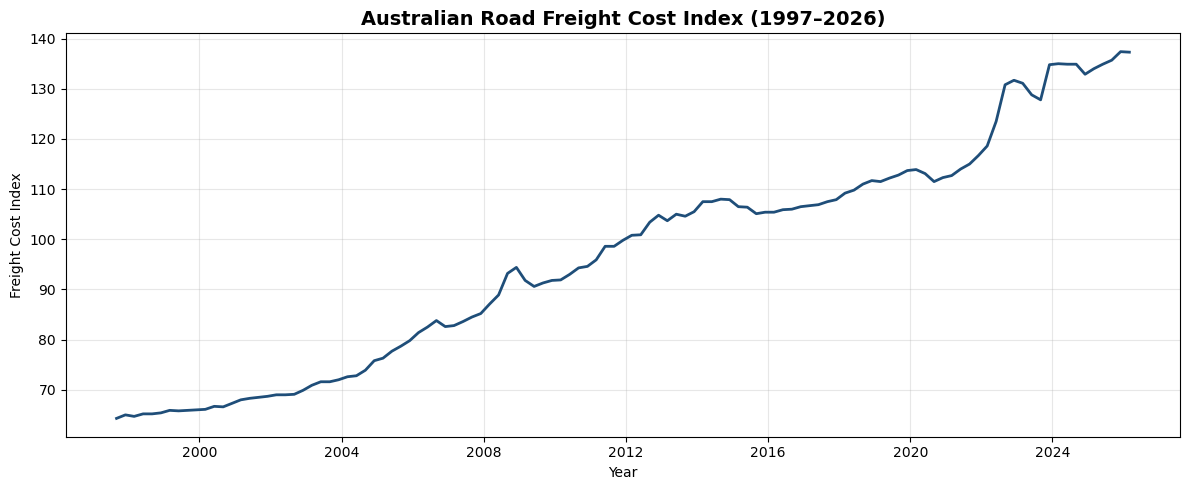

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df["quarter_date"], df["freight_cost"], color="#1f4e79", linewidth=2)

ax.set_title("Australian Road Freight Cost Index (1997–2026)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Freight Cost Index")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

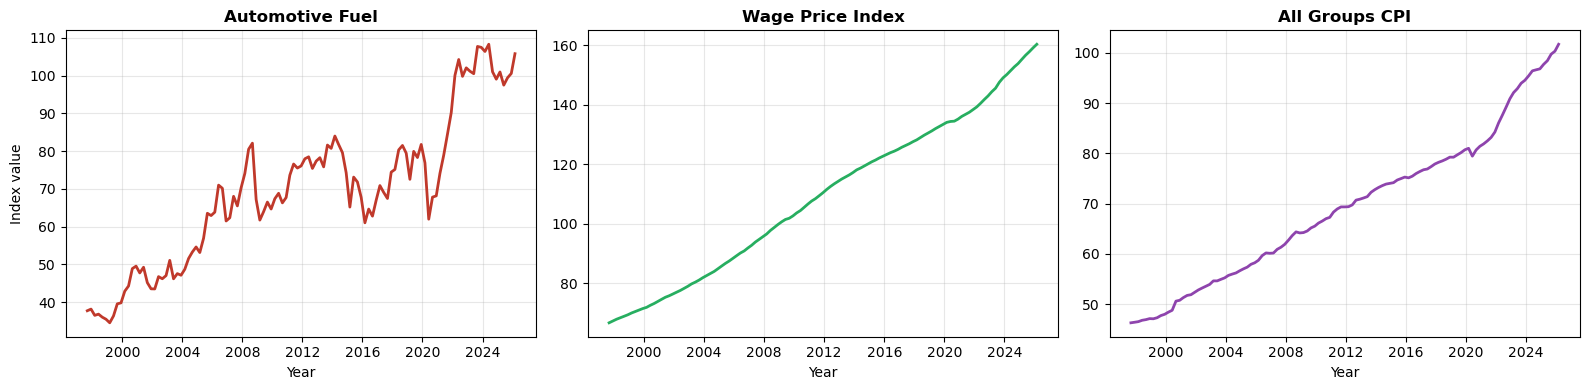

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

drivers = [
    ("fuel_index", "Automotive Fuel", "#c0392b"),
    ("wage_index", "Wage Price Index", "#27ae60"),
    ("cpi_index",  "All Groups CPI",  "#8e44ad"),
]

for ax, (col, label, colour) in zip(axes, drivers):
    ax.plot(df["quarter_date"], df[col], color=colour, linewidth=2)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Year")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Index value")
plt.tight_layout()
plt.show()

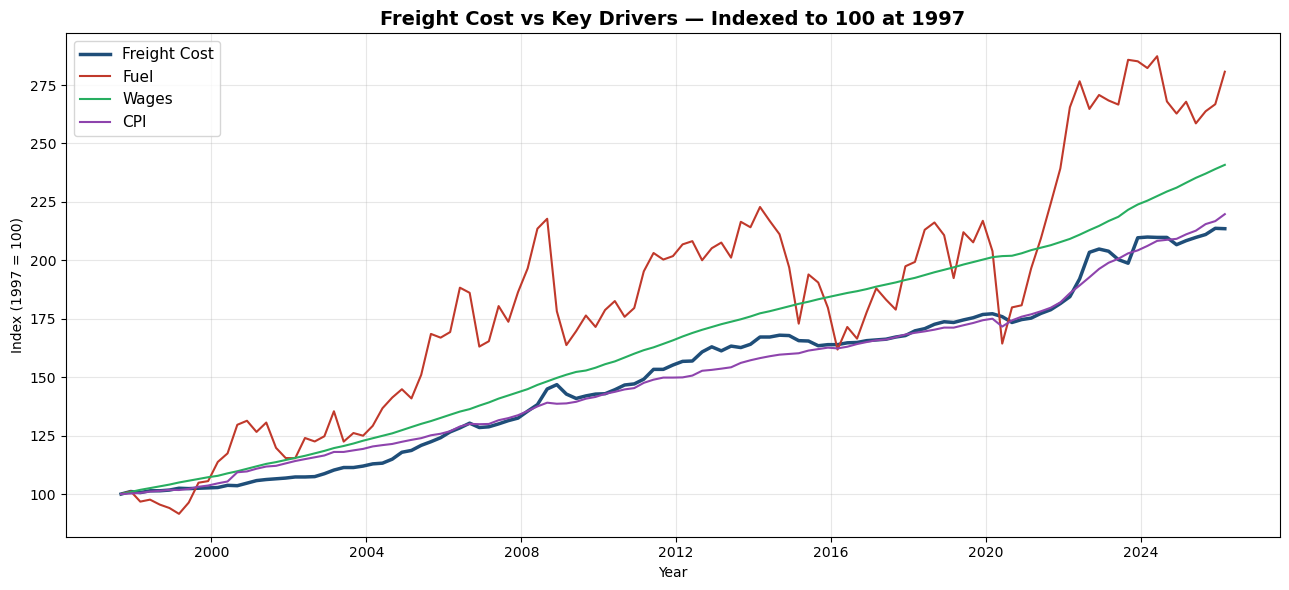

In [5]:
# Rebase every series to 100 at its first value -> growth becomes comparable
normalised = df.copy()
for col in ["freight_cost", "fuel_index", "wage_index", "cpi_index"]:
    normalised[col] = df[col] / df[col].iloc[0] * 100

fig, ax = plt.subplots(figsize=(13, 6))

series = [
    ("freight_cost", "Freight Cost", "#1f4e79", 2.5),
    ("fuel_index",   "Fuel",         "#c0392b", 1.5),
    ("wage_index",   "Wages",        "#27ae60", 1.5),
    ("cpi_index",    "CPI",          "#8e44ad", 1.5),
]

for col, label, colour, width in series:
    ax.plot(normalised["quarter_date"], normalised[col],
            label=label, color=colour, linewidth=width)

ax.set_title("Freight Cost vs Key Drivers — Indexed to 100 at 1997",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Index (1997 = 100)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()